In [1]:
from lib.contact_settings import *
from lib.contact_material import material
from lib.geoLib.contact_wheel_rail import wheel, rail
from lib.dynLib.contact_dyn_state import dynamic_state
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pio_normal_contact
from lib.normLib.contact_solver import NormalContactSolver

import matplotlib.pyplot as plt

In [2]:
dy = 0.05e-3
deltays = np.array([0])

Wheel = wheel()
Rail = rail(rail_inclination=30)

material_model = material()

n_patches = 3
contact_eq = NormalContactSolver(eqv_el_normal_contact(), n_patches)

new_state = dynamic_state(state_z=1e-4)
Wheel.set_dynamic_state(new_state)
Wheel.calculate_position()

contact_eq.patch_search(Wheel, Rail, material_model)

In [3]:
data = []

for jj in range(contact_eq.n_patches):

    data.append(
        [
            contact_eq.contact_patches[jj].normal_force,
            contact_eq.contact_patches[jj].contact_angle,
            contact_eq.contact_patches[jj].Q_force,
            contact_eq.contact_patches[jj].Y_force,
            contact_eq.contact_patches[jj].semi_axis_a*1e3,
            contact_eq.contact_patches[jj].semi_axis_b*1e3,
        ]
    )

print(f"{'Normal force [N]':<20} {'Contact angle [deg]':<20} {'Q force [N]':<20} {'Y force [N]':<20} {'ellips a [mm]':<20} {'ellips b [mm]':<20}")
for row in data:
    print(f"{row[0]:<20.2f} {row[1]:<20.2f} {row[2]:<20.2f} {row[3]:<20.2f} {row[4]:<20.2f} {row[5]:<20.2f}")


Normal force [N]     Contact angle [deg]  Q force [N]          Y force [N]          ellips a [mm]        ellips b [mm]       
82124.11             0.02                 82113.64             1311.53              6.42                 6.78                
0.00                 0.00                 0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                 0.00                 0.00                


In [4]:
from lib.tanLib.tangent_methods import fastsim, tangent_creepage

fastsim_patch = fastsim()
creep = tangent_creepage(nu_x=0.001, nu_y=0.000, phi=0.5)

new_state_0 = dynamic_state(state_v_x=100/3.6)
fastsim.calc_tangent_force(fastsim_patch, contact_eq.contact_patches[0], material_model, creep, new_state_0)

In [5]:
print(fastsim_patch.F_x, fastsim_patch.F_y)

-8404.406796904412 -14238.76647560272


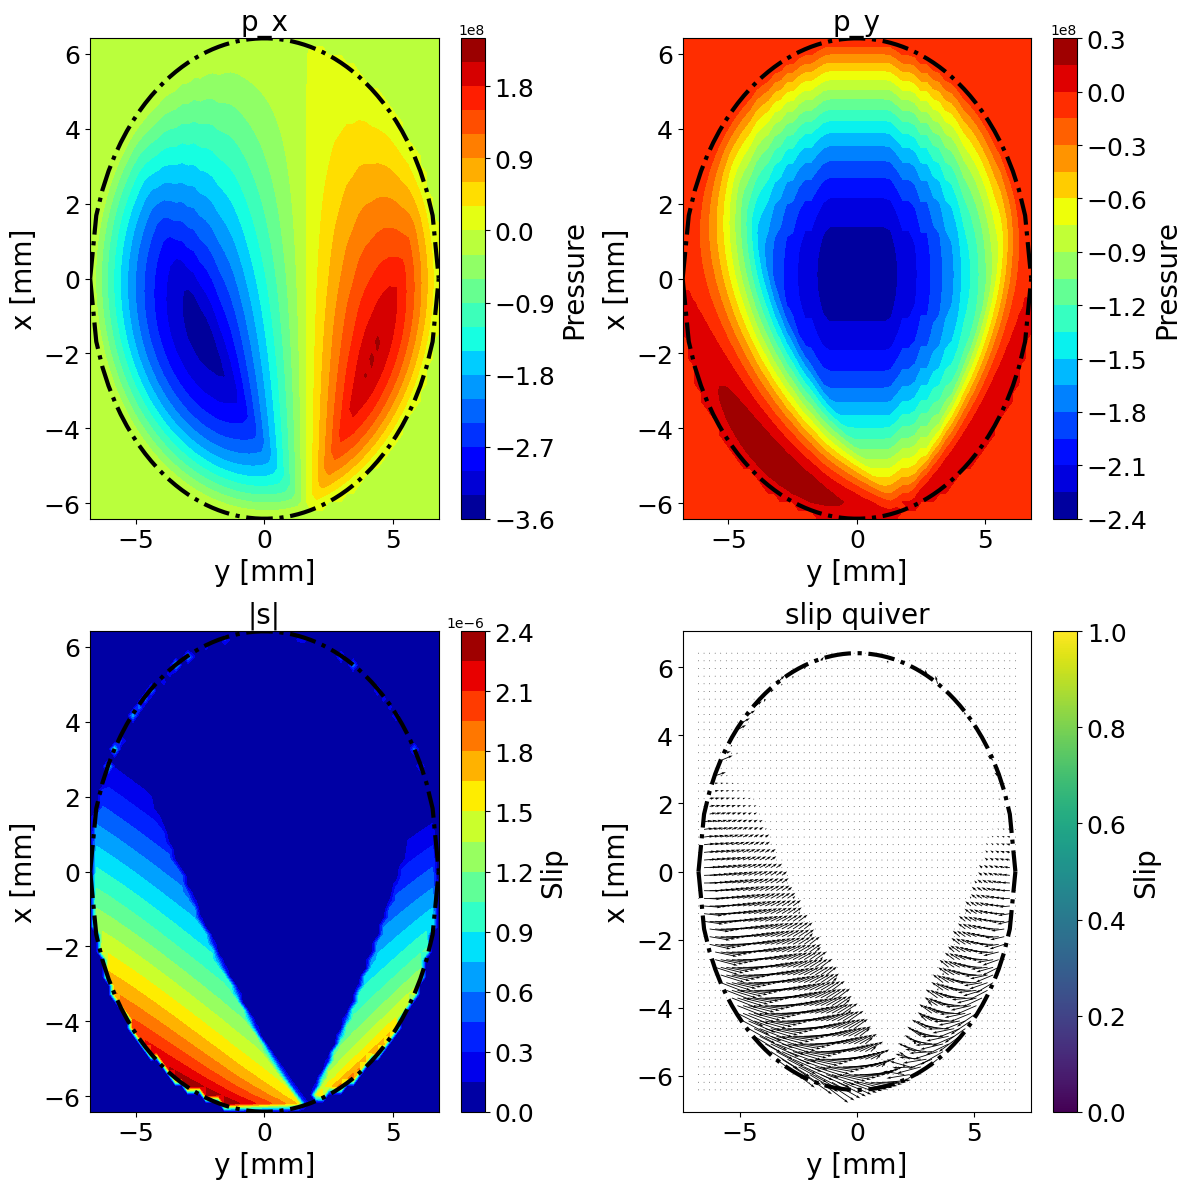

In [7]:
b_ = np.linspace(
    -contact_eq.contact_patches[0].semi_axis_b,
    contact_eq.contact_patches[0].semi_axis_b,
    58,
)
a_ = contact_eq.contact_patches[0].semi_axis_a * np.sqrt(
    1 - (b_**2) / (contact_eq.contact_patches[0].semi_axis_b ** 2)
)

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 12))
c = ax[0,0].contourf(fastsim_patch.yy * 1e3, fastsim_patch.xx * 1e3, fastsim_patch.p_x, levels=20, cmap='jet')
ax[0,0].plot(b_ * 1e3, a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[0,0].plot(b_ * 1e3, -a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[0,0].set_title('p_x', fontsize = 20)
ax[0,0].set_xlabel("y [mm]", fontsize=20)
ax[0,0].set_ylabel("x [mm]", fontsize=20)
ax[0,0].tick_params(axis="both", labelsize=18)
cbar = fig.colorbar(c, ax=ax[0,0])
cbar.set_label("Pressure", fontsize=20)
cbar.ax.tick_params(labelsize=18)

c = ax[0,1].contourf(fastsim_patch.yy * 1e3, fastsim_patch.xx * 1e3, fastsim_patch.p_y, levels=20, cmap='jet')
ax[0,1].plot(b_ * 1e3, a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[0,1].plot(b_ * 1e3, -a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[0,1].set_title('p_y', fontsize = 20)
ax[0,1].set_xlabel("y [mm]", fontsize=20)
ax[0,1].set_ylabel("x [mm]", fontsize=20)
ax[0,1].tick_params(axis="both", labelsize=18)
cbar = fig.colorbar(c, ax=ax[0,1])
cbar.set_label("Pressure", fontsize=20)
cbar.ax.tick_params(labelsize=18)

c = ax[1,0].contourf(fastsim_patch.yy * 1e3, fastsim_patch.xx * 1e3, fastsim_patch.s_out, levels=20, cmap='jet')
ax[1,0].plot(b_ * 1e3, a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[1,0].plot(b_ * 1e3, -a_ * 1e3, color="black", linestyle="-.",linewidth=3)
ax[1,0].set_title('|s|', fontsize = 20)
ax[1,0].set_xlabel("y [mm]", fontsize=20)
ax[1,0].set_ylabel("x [mm]", fontsize=20)
ax[1,0].tick_params(axis="both", labelsize=18)
cbar = fig.colorbar(c, ax=ax[1,0])
cbar.set_label("Slip", fontsize=20)
cbar.ax.tick_params(labelsize=18)

c = ax[1,1].quiver(fastsim_patch.yy * 1e3, fastsim_patch.xx * 1e3, fastsim_patch.s_x, fastsim_patch.s_y, scale=3)
ax[1,1].plot(b_ * 1e3, a_ * 1e3, color="black", linestyle="-.", linewidth=3)
ax[1,1].plot(b_ * 1e3, -a_ * 1e3, color="black", linestyle="-.", linewidth=3)
ax[1,1].set_title('slip quiver', fontsize = 20)
ax[1,1].set_xlabel("y [mm]", fontsize=20)
ax[1,1].set_ylabel("x [mm]", fontsize=20)
ax[1,1].tick_params(axis="both", labelsize=18)
cbar = fig.colorbar(c, ax=ax[1,1])
cbar.set_label("Slip", fontsize=20)
cbar.ax.tick_params(labelsize=18)

fig.tight_layout()
plt.show()